# SkinXAI v5 — Kaggle Versiyonu

## Notebook'u çalıştırmadan önce:

**1. Dataset ekle (sağ panelde "Add Data"):**
- `kmader/skin-lesion-analysis-toward-melanoma-detection` → HAM10000
- `andrewmvd/isic-2019` → ISIC 2019

**2. GPU aç:**
- Sağ panel → Settings → Accelerator → **GPU T4 x2** → Save

**3. Hücreleri sırayla çalıştır.**

Model ve grafikler `/kaggle/working/` klasörüne kaydedilir.  
Notebook bitince sağ paneldeki **Output** sekmesinden indirebilirsin.

In [1]:
# ── 1. Kurulum ──────────────────────────────────────────────────
!pip install timm albumentations -q

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import cv2, os, random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
import warnings; warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Cihaz: {device}')
if torch.cuda.is_available():
    print(f'GPU  : {torch.cuda.get_device_name(0)}')
else:
    print('⚠️  GPU YOK — Settings → Accelerator → GPU T4 x2 seç!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 89.2 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which

In [9]:
# ── 2. Sabitler & Yollar ────────────────────────────────────────
# Kaggle dataset add'den ekledikten sonra bu yollar otomatik hazır
HAM_DIR = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
ISIC_DIR = '/kaggle/input/datasets/cdeotte/jpeg-isic2019-384x384'
SAVE_DIR = '/kaggle/working/models_v5'
SAVE_PATH = f'{SAVE_DIR}/skinxai_v5_best.pth'
os.makedirs(SAVE_DIR, exist_ok=True)

CLASS_NAMES = ['ak', 'bcc', 'bkl', 'df', 'melanoma', 'nevus', 'scc', 'vasc']
LABEL2IDX   = {n: i for i, n in enumerate(CLASS_NAMES)}
IDX2LABEL   = {i: n for n, i in LABEL2IDX.items()}
IMG_SIZE    = 224
BATCH_SIZE  = 32

V5_TARGETS = {
    'melanoma': 4500,
    'scc':      2500,   # 628 → ×4 oversample (en kritik)
    'bcc':      3000,
    'bkl':      2500,
    'ak':       2000,
    'df':       1500,
    'vasc':     1500,
    'nevus':    3000,   # 19580 → sert cap
}

# Dataset varlığını doğrula
print('Dataset kontrolü:')
print(f'  HAM10000 var mı : {os.path.exists(HAM_DIR)}')
print(f'  ISIC 2019 var mı: {os.path.exists(ISIC_DIR)}')
print()
if os.path.exists(HAM_DIR):
    print('  HAM içeriği:', os.listdir(HAM_DIR)[:8])
if os.path.exists(ISIC_DIR):
    print('  ISIC içeriği:', os.listdir(ISIC_DIR)[:8])

Dataset kontrolü:
  HAM10000 var mı : True
  ISIC 2019 var mı: True

  HAM içeriği: ['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'HAM10000_images_part_2', 'ham10000_images_part_2', 'hmnist_28_28_L.csv']
  ISIC içeriği: ['train.csv', 'train']


In [10]:
# ── 3. HAM10000 Yükle ───────────────────────────────────────────
def load_ham10000(ham_dir):
    HAM_LABEL_MAP = {
        'nv':'nevus', 'mel':'melanoma', 'bcc':'bcc',
        'bkl':'bkl',  'df':'df',        'vasc':'vasc',
        'akiec':'ak',   # AK + SCC in situ → ak (SCC için kullanılmaz)
    }
    # Tüm alt klasörleri tara
    img_index = {}
    for root, _, files in os.walk(ham_dir):
        for f in files:
            if f.lower().endswith(('.jpg','.jpeg','.png')):
                img_index[os.path.splitext(f)[0]] = os.path.join(root, f)
    print(f'  İndekslenen görüntü: {len(img_index)}')

    # metadata CSV — birkaç olası isim dene
    csv_candidates = [
        os.path.join(ham_dir, 'HAM10000_metadata.csv'),
        os.path.join(ham_dir, 'ham10000_metadata.csv'),
    ]
    meta = None
    for p in csv_candidates:
        if os.path.exists(p):
            meta = pd.read_csv(p); break
    if meta is None:
        raise FileNotFoundError(f'HAM metadata CSV bulunamadı. Klasör: {os.listdir(ham_dir)[:10]}')

    records, missing = [], 0
    for _, row in meta.iterrows():
        img_id = row['image_id']
        dx     = str(row['dx']).lower().strip()
        if dx not in HAM_LABEL_MAP: continue
        path = img_index.get(img_id)
        if path is None: missing += 1; continue
        records.append({'image_path': path, 'label': HAM_LABEL_MAP[dx], 'source': 'ham'})

    df = pd.DataFrame(records)
    print(f'HAM10000: {len(df)} görüntü  ({missing} eksik)')
    print(df['label'].value_counts().to_string())
    return df

ham_df = load_ham10000(HAM_DIR)

  İndekslenen görüntü: 10015
HAM10000: 10015 görüntü  (0 eksik)
label
nevus       6705
melanoma    1113
bkl         1099
bcc          514
ak           327
vasc         142
df           115


In [11]:
# ── 4. ISIC 2019 Yükle ──────────────────────────────────────────
def load_isic2019(isic_dir):
    csv_path = os.path.join(isic_dir, 'train.csv')
    img_dir  = os.path.join(isic_dir, 'train')
    df_raw   = pd.read_csv(csv_path)
    print(f'  Kolonlar: {list(df_raw.columns[:6])}')

    DIAG_MAP = {
        'nv':'nevus',   'mel':'melanoma', 'bcc':'bcc',  'ak':'ak',
        'scc':'scc',    'bkl':'bkl',      'df':'df',    'vasc':'vasc',
        'melanoma':'melanoma', 'nevus':'nevus',
        'seborrheic keratosis':'bkl', 'lentigo nos':'bkl',
        'lichenoid keratosis':'bkl',  'solar lentigo':'bkl',
        'basal cell carcinoma':'bcc', 'squamous cell carcinoma':'scc',
        'actinic keratosis':'ak',     'vascular lesion':'vasc',
        'dermatofibroma':'df',
    }

    records = []
    for _, row in df_raw.iterrows():
        label = DIAG_MAP.get(str(row.get('diagnosis','')).lower().strip())
        if label is None:
            continue
        img_name = str(row['image_name'])
        for ext in ['', '.jpg', '.jpeg', '.png']:
            path = os.path.join(img_dir, img_name + ext)
            if os.path.exists(path):
                records.append({'image_path': path, 'label': label, 'source': 'isic'})
                break

    df = pd.DataFrame(records)
    print(f'ISIC 2019: {len(df)} görüntü')
    print(df['label'].value_counts().to_string())
    return df

isic_df = load_isic2019(ISIC_DIR)

  Kolonlar: ['image_name', 'patient_id', 'sex', 'age_approx', 'anatom_site_general_challenge', 'diagnosis']
ISIC 2019: 25331 görüntü
label
nevus       12875
melanoma     4522
bcc          3323
bkl          2624
ak            867
scc           628
vasc          253
df            239


In [12]:
# ── 5. Birleştir → Train/Val/Test Split (80/10/10) ──────────────
combined_df = pd.concat([ham_df, isic_df], ignore_index=True)
combined_df['label_idx'] = combined_df['label'].map(LABEL2IDX)

print('Birleşik dağılım:')
vc = combined_df['label'].value_counts()
for cls in CLASS_NAMES:
    n = vc.get(cls, 0)
    print(f'  {cls:12s}: {n:6d}')
print(f'  {"TOPLAM":12s}: {len(combined_df):6d}')

train_val, test_pool = train_test_split(
    combined_df, test_size=0.10, stratify=combined_df['label'], random_state=SEED)
train_pool, val_pool = train_test_split(
    train_val, test_size=0.111, stratify=train_val['label'], random_state=SEED)

print(f'\nTrain pool : {len(train_pool)}')
print(f'Val        : {len(val_pool)}')
print(f'Test       : {len(test_pool)}')

train_pool.to_csv(f'{SAVE_DIR}/train_pool.csv', index=False)
val_pool.to_csv(f'{SAVE_DIR}/val_df.csv',       index=False)
test_pool.to_csv(f'{SAVE_DIR}/test_df.csv',     index=False)

Birleşik dağılım:
  ak          :   1194
  bcc         :   3837
  bkl         :   3723
  df          :    354
  melanoma    :   5635
  nevus       :  19580
  scc         :    628
  vasc        :    395
  TOPLAM      :  35346

Train pool : 28279
Val        : 3532
Test       : 3535


In [13]:
# ── 6. Dengeli Sampling ─────────────────────────────────────────
def build_balanced(df, targets, seed=42):
    parts = []
    print(f'  {"Sınıf":12s} {"Mevcut":>7} {"Hedef":>7} {"İşlem":>18}')
    print('  ' + '-'*50)
    for cls, target in sorted(targets.items()):
        sub = df[df['label'] == cls].sample(frac=1, random_state=seed)
        n   = len(sub)
        if n == 0: print(f'  {cls}: VERİ YOK'); continue
        if n >= target:
            sampled = sub.iloc[:target]; op = 'cap'
        else:
            reps = target // n; rem = target % n
            sampled = pd.concat([sub]*reps + [sub.iloc[:rem]], ignore_index=True)
            op = f'oversample ×{target/n:.1f}'
        parts.append(sampled)
        print(f'  {cls:12s} {n:7d} {target:7d} {op:>18}')
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

print('v5 Train seti:')
train_df = build_balanced(train_pool, V5_TARGETS)
train_df['label_idx'] = train_df['label'].map(LABEL2IDX)
val_pool  = val_pool.copy();  val_pool['label_idx']  = val_pool['label'].map(LABEL2IDX)
test_pool = test_pool.copy(); test_pool['label_idx'] = test_pool['label'].map(LABEL2IDX)
print(f'\nToplam train: {len(train_df)}')

v5 Train seti:
  Sınıf         Mevcut   Hedef              İşlem
  --------------------------------------------------
  ak               956    2000    oversample ×2.1
  bcc             3070    3000                cap
  bkl             2979    2500                cap
  df               283    1500    oversample ×5.3
  melanoma        4508    4500                cap
  nevus          15665    3000                cap
  scc              502    2500    oversample ×5.0
  vasc             316    1500    oversample ×4.7

Toplam train: 20500


In [14]:
# ── 7. Augmentation ─────────────────────────────────────────────
NORM = A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
S    = IMG_SIZE

AUG_HIGH_RISK = A.Compose([   # Melanoma + SCC: renk ağırlıklı
    A.Resize(S,S), A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
    A.Rotate(limit=90, p=0.7),
    A.HueSaturationValue(hue_shift_limit=25, sat_shift_limit=40, val_shift_limit=20, p=0.75),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.75),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8,8), p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.3, hue=0.1, p=0.5),
    A.CoarseDropout(max_holes=6, max_height=S//8, max_width=S//8, fill_value=0, p=0.3),
    NORM, ToTensorV2(),
])

AUG_MINORITY = A.Compose([    # AK, DF, VASC: geometrik ağırlıklı
    A.Resize(S,S), A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
    A.Rotate(limit=180, p=0.8),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=35, val_shift_limit=20, p=0.6),
    A.OneOf([A.GridDistortion(p=1.0), A.ElasticTransform(alpha=120, sigma=6, p=1.0)], p=0.4),
    A.CoarseDropout(max_holes=8, max_height=S//8, max_width=S//8, fill_value=0, p=0.35),
    NORM, ToTensorV2(),
])

AUG_MEDIUM = A.Compose([      # BCC, BKL: standart
    A.Resize(S,S), A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.3),
    A.Rotate(limit=90, p=0.5), A.RandomBrightnessContrast(p=0.5),
    A.HueSaturationValue(p=0.4), NORM, ToTensorV2(),
])

AUG_NEVUS = A.Compose([       # Nevus: minimal
    A.Resize(S,S), A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3), NORM, ToTensorV2(),
])

AUG_VAL = A.Compose([A.Resize(S,S), NORM, ToTensorV2()])

CLASS_AUG = {
    'melanoma': AUG_HIGH_RISK, 'scc': AUG_HIGH_RISK,
    'ak': AUG_MINORITY,        'df':  AUG_MINORITY,  'vasc': AUG_MINORITY,
    'bcc': AUG_MEDIUM,         'bkl': AUG_MEDIUM,
    'nevus': AUG_NEVUS,
}
print('Augmentation hazır. melanoma+scc → renk, ak+df+vasc → geometrik')

Augmentation hazır. melanoma+scc → renk, ak+df+vasc → geometrik


In [15]:
# ── 8. Dataset & DataLoader ─────────────────────────────────────
def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

def mixup_criterion(crit, pred, y_a, y_b, lam):
    return lam*crit(pred,y_a) + (1-lam)*crit(pred,y_b)


class SkinDataset(Dataset):
    def __init__(self, df, is_train=True):
        self.df = df.reset_index(drop=True)
        self.is_train = is_train
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['image_path'])
        if img is None: img = np.zeros((IMG_SIZE,IMG_SIZE,3), dtype=np.uint8)
        else:           img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        tfm = CLASS_AUG[row['label']] if self.is_train else AUG_VAL
        return tfm(image=img)['image'], int(row['label_idx'])


train_ds = SkinDataset(train_df, True)
val_ds   = SkinDataset(val_pool,  False)
test_ds  = SkinDataset(test_pool, False)

NW = 2
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=NW, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=NW, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=NW, pin_memory=True)

print(f'Train: {len(train_ds):6d} ({len(train_loader)} batch)')
print(f'Val  : {len(val_ds):6d}')
print(f'Test : {len(test_ds):6d}')

Train:  20500 (641 batch)
Val  :   3532
Test :   3535


In [16]:
# ── 9. Model — EfficientNetV2-S, ImageNet Pretrained ────────────
class SkinModel(nn.Module):
    def __init__(self, num_classes=8, dropout=0.4):
        super().__init__()
        self.backbone = timm.create_model(
            'tf_efficientnetv2_s', pretrained=True,
            num_classes=0, global_pool='avg')
        d = self.backbone.num_features
        self.head = nn.Sequential(
            nn.BatchNorm1d(d),
            nn.Dropout(dropout),
            nn.Linear(d, 512),
            nn.SiLU(),
            nn.Dropout(dropout*0.5),
            nn.Linear(512, num_classes),
        )
    def forward(self, x):
        return self.head(self.backbone(x))

model = SkinModel(8).to(device)
print(f'Model hazır  |  {sum(p.numel() for p in model.parameters())/1e6:.1f}M parametre')

model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

Model hazır  |  20.8M parametre


In [18]:
# ── 10. Loss & Class Weights ────────────────────────────────────
class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes=8, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing; self.cls = classes; self.weight = weight
    def forward(self, pred, target):
        c   = 1.0 - self.smoothing; s = self.smoothing / (self.cls - 1)
        oh  = torch.zeros_like(pred).scatter_(1, target.unsqueeze(1), 1)
        soh = oh * c + (1-oh) * s
        lp  = F.log_softmax(pred, dim=1)
        if self.weight is not None:
            loss = -(soh * lp * self.weight[target].unsqueeze(1)).sum(1).mean()
        else:
            loss = -(soh * lp).sum(1).mean()
        return loss

w = compute_class_weight('balanced', classes=np.arange(8), y=train_df['label_idx'].values)
w[CLASS_NAMES.index('scc')]      *= 1.5   # en kritik
w[CLASS_NAMES.index('melanoma')] *= 1.8
w[CLASS_NAMES.index('ak')]       *= 1.2
w[CLASS_NAMES.index('bcc')]      *= 1.1
w = w / w.mean()
weights_t = torch.FloatTensor(w).to(device)
criterion = LabelSmoothingLoss(8, 0.1, weights_t)

print('Sınıf ağırlıkları:')
for n, wi in zip(CLASS_NAMES, w):
    print(f'  {n:12s}: {wi:.3f}  {"█"*int(wi*8)}')

Sınıf ağırlıkları:
  ak          : 1.190  █████████
  bcc         : 0.727  █████
  bkl         : 0.793  ██████
  df          : 1.322  ██████████
  melanoma    : 0.793  ██████
  nevus       : 0.661  █████
  scc         : 1.190  █████████
  vasc        : 1.322  ██████████


In [19]:
# ── 11. Eğitim Fonksiyonları ────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device, mixup=True):
    model.train()
    tot_loss = cor = tot = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        if mixup and random.random() < 0.4:
            xm, ya, yb, lam = mixup_data(imgs, labels)
            out  = model(xm)
            loss = mixup_criterion(criterion, out, ya, yb, lam)
            cor += (lam*(out.argmax(1)==ya).float()+(1-lam)*(out.argmax(1)==yb).float()).sum().item()
        else:
            out  = model(imgs)
            loss = criterion(out, labels)
            cor += (out.argmax(1)==labels).sum().item()
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tot_loss += loss.item()*imgs.size(0); tot += imgs.size(0)
    return tot_loss/tot, cor/tot

@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    preds, labels = [], []
    for imgs, labs in loader:
        preds.extend(model(imgs.to(device)).argmax(1).cpu().numpy())
        labels.extend(labs.numpy())
    preds, labels = np.array(preds), np.array(labels)
    return ((preds==labels).mean(),
            f1_score(labels, preds, average='macro', zero_division=0),
            recall_score(labels, preds, average=None, zero_division=0),
            preds, labels)

def log(tag, ep, tot, loss, tacc, vacc, vf1, pc, ni, pat, saved=''):
    mel = pc[CLASS_NAMES.index('melanoma')]; scc = pc[CLASS_NAMES.index('scc')]
    nev = pc[CLASS_NAMES.index('nevus')];    bcc = pc[CLASS_NAMES.index('bcc')]
    mf  = '🟢' if mel>=0.65 else ('🟡' if mel>=0.55 else '🔴')
    sf  = '🟢' if scc>=0.60 else ('🟡' if scc>=0.45 else '🔴')
    print(f'[{tag} {ep:2d}/{tot}] L={loss:.4f} Acc={tacc:.3f} | '
          f'Val acc={vacc:.3f} f1={vf1:.4f} '
          f'mel={mel:.2f}{mf} scc={scc:.2f}{sf} '
          f'nev={nev:.2f} bcc={bcc:.2f} (p{ni}/{pat}){saved}')

print('Fonksiyonlar hazır.')

Fonksiyonlar hazır.


In [20]:
# ── 12. Phase 1 — Backbone Dondurulmuş (5 Epoch) ───────────────
for p in model.backbone.parameters(): p.requires_grad = False
for p in model.head.parameters():     p.requires_grad = True

opt1   = torch.optim.AdamW(model.head.parameters(), lr=1e-3, weight_decay=1e-3)
sched1 = torch.optim.lr_scheduler.OneCycleLR(
    opt1, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=5, pct_start=0.3)

best_f1 = 0.0; best_ep = 0; ni = 0; history = []
print('='*70)
print('Phase 1 — Backbone frozen | Sadece head eğitimi (5 epoch)')
print('='*70)

for ep in range(1, 6):
    tl, ta = train_epoch(model, train_loader, opt1, criterion, device, mixup=False)
    va, vf, pc, *_ = eval_epoch(model, val_loader, device)
    sched1.step()
    history.append(dict(phase=1, ep=ep, tl=tl, vf=vf, pc=pc.tolist()))
    sv = ''
    if vf > best_f1:
        best_f1=vf; best_ep=ep; ni=0
        torch.save({'epoch':ep,'model_state_dict':model.state_dict(),
                    'val_f1':vf,'per_class_recall':pc.tolist(),
                    'best_f1':best_f1,'class_names':CLASS_NAMES}, SAVE_PATH)
        sv=' ✅'
    else: ni+=1
    log('P1', ep, 5, tl, ta, va, vf, pc, ni, 3, sv)

print(f'\nPhase 1 bitti. Best Val F1: {best_f1:.4f}')

Phase 1 — Backbone frozen | Sadece head eğitimi (5 epoch)
[P1  1/5] L=1.5042 Acc=0.486 | Val acc=0.626 f1=0.3464 mel=0.19🔴 scc=0.03🔴 nev=0.83 bcc=0.74 (p0/3) ✅
[P1  2/5] L=1.2968 Acc=0.587 | Val acc=0.642 f1=0.3943 mel=0.19🔴 scc=0.05🔴 nev=0.82 bcc=0.78 (p0/3) ✅
[P1  3/5] L=1.2599 Acc=0.607 | Val acc=0.657 f1=0.3997 mel=0.17🔴 scc=0.11🔴 nev=0.87 bcc=0.74 (p0/3) ✅
[P1  4/5] L=1.2447 Acc=0.612 | Val acc=0.655 f1=0.4181 mel=0.18🔴 scc=0.13🔴 nev=0.84 bcc=0.78 (p0/3) ✅
[P1  5/5] L=1.2316 Acc=0.621 | Val acc=0.651 f1=0.4103 mel=0.15🔴 scc=0.06🔴 nev=0.84 bcc=0.78 (p1/3)

Phase 1 bitti. Best Val F1: 0.4181


In [22]:
# ── 13. Phase 2 — Tam Eğitim (30 Epoch) ────────────────────────
for p in model.parameters(): p.requires_grad = True

opt2 = torch.optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': 1e-5},
    {'params': model.head.parameters(),     'lr': 1e-4},
], weight_decay=1e-4)

sched2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt2, mode='max', factor=0.5, patience=4, min_lr=1e-8)

P2 = 30; PAT = 8; ni = 0
print('='*70)
print(f'Phase 2 — Full fine-tune | Başlangıç F1: {best_f1:.4f}')
print('='*70)

for ep in range(1, P2+1):
    tl, ta   = train_epoch(model, train_loader, opt2, criterion, device, mixup=True)
    va, vf, pc, *_ = eval_epoch(model, val_loader, device)
    sched2.step(vf)
    history.append(dict(phase=2, ep=ep, tl=tl, vf=vf, pc=pc.tolist()))
    sv = ''
    if vf > best_f1:
        best_f1=vf; best_ep=ep; ni=0
        torch.save({'epoch':ep,'model_state_dict':model.state_dict(),
                    'optimizer_state_dict':opt2.state_dict(),
                    'val_acc':va,'val_f1':vf,'per_class_recall':pc.tolist(),
                    'best_f1':best_f1,'history':history,'class_names':CLASS_NAMES}, SAVE_PATH)
        sv=' ✅'
    else: ni+=1
    log('P2', ep, P2, tl, ta, va, vf, pc, ni, PAT, sv)
    if ni >= PAT:
        print(f'\nEarly stopping ({PAT} epoch iyileşme yok).')
        break

print(f'\nPhase 2 bitti. Best F1: {best_f1:.4f} (epoch {best_ep})')

Phase 2 — Full fine-tune | Başlangıç F1: 0.4181
[P2  1/30] L=1.2372 Acc=0.620 | Val acc=0.687 f1=0.4624 mel=0.16🔴 scc=0.19🔴 nev=0.87 bcc=0.82 (p0/8) ✅
[P2  2/30] L=1.1425 Acc=0.677 | Val acc=0.710 f1=0.4927 mel=0.20🔴 scc=0.14🔴 nev=0.90 bcc=0.87 (p0/8) ✅
[P2  3/30] L=1.1054 Acc=0.696 | Val acc=0.722 f1=0.5115 mel=0.17🔴 scc=0.11🔴 nev=0.92 bcc=0.88 (p0/8) ✅
[P2  4/30] L=1.0647 Acc=0.721 | Val acc=0.728 f1=0.5488 mel=0.14🔴 scc=0.22🔴 nev=0.92 bcc=0.88 (p0/8) ✅
[P2  5/30] L=1.0292 Acc=0.739 | Val acc=0.732 f1=0.5526 mel=0.13🔴 scc=0.14🔴 nev=0.94 bcc=0.87 (p0/8) ✅
[P2  6/30] L=0.9909 Acc=0.760 | Val acc=0.733 f1=0.5701 mel=0.15🔴 scc=0.24🔴 nev=0.91 bcc=0.91 (p0/8) ✅
[P2  7/30] L=0.9836 Acc=0.765 | Val acc=0.746 f1=0.5801 mel=0.16🔴 scc=0.14🔴 nev=0.94 bcc=0.89 (p0/8) ✅
[P2  8/30] L=0.9573 Acc=0.777 | Val acc=0.748 f1=0.6115 mel=0.18🔴 scc=0.33🔴 nev=0.91 bcc=0.89 (p0/8) ✅
[P2  9/30] L=0.9378 Acc=0.788 | Val acc=0.754 f1=0.6083 mel=0.19🔴 scc=0.25🔴 nev=0.92 bcc=0.90 (p1/8)
[P2 10/30] L=0.9110 Acc=0.8

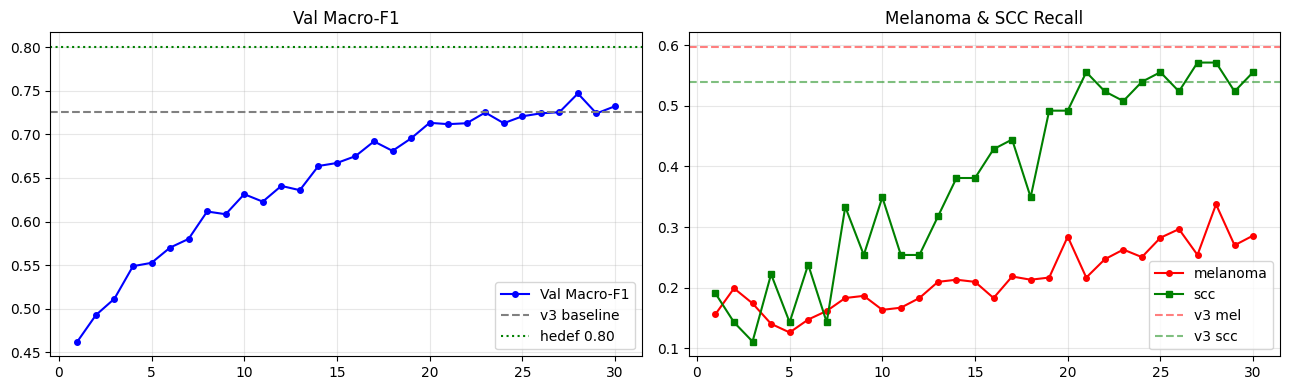

In [23]:
# ── 14. Learning Curve ──────────────────────────────────────────
p2h = [h for h in history if h['phase']==2]
if p2h:
    ep   = [h['ep']  for h in p2h]
    f1s  = [h['vf']  for h in p2h]
    mels = [h['pc'][CLASS_NAMES.index('melanoma')] for h in p2h]
    sccs = [h['pc'][CLASS_NAMES.index('scc')]      for h in p2h]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,4))
    ax1.plot(ep, f1s,  'b-o', ms=4, label='Val Macro-F1')
    ax1.axhline(0.725, c='gray', ls='--', label='v3 baseline')
    ax1.axhline(0.80,  c='green', ls=':', label='hedef 0.80')
    ax1.set_title('Val Macro-F1'); ax1.legend(); ax1.grid(alpha=.3)

    ax2.plot(ep, mels, 'r-o', ms=4, label='melanoma')
    ax2.plot(ep, sccs, 'g-s', ms=4, label='scc')
    ax2.axhline(0.597, c='r', ls='--', alpha=.5, label='v3 mel')
    ax2.axhline(0.540, c='g', ls='--', alpha=.5, label='v3 scc')
    ax2.set_title('Melanoma & SCC Recall'); ax2.legend(); ax2.grid(alpha=.3)

    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/curve_v5.png', dpi=150, bbox_inches='tight')
    plt.show()

In [24]:
# ── 15. Test & TTA Değerlendirmesi ──────────────────────────────
ckpt = torch.load(SAVE_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Best model: Val F1={ckpt["val_f1"]:.4f} | Epoch={ckpt["epoch"]}')

# Argmax
ta, tf, pc, tp, tl = eval_epoch(model, test_loader, device)
print(f'\nTest argmax:  Acc={ta:.4f}  F1={tf:.4f}')
print(classification_report(tl, tp, target_names=CLASS_NAMES, digits=3))

# TTA
TTA_T = [
    A.Compose([A.Resize(224,224), NORM, ToTensorV2()]),
    A.Compose([A.Resize(224,224), A.HorizontalFlip(p=1), NORM, ToTensorV2()]),
    A.Compose([A.Resize(224,224), A.VerticalFlip(p=1),   NORM, ToTensorV2()]),
    A.Compose([A.Resize(256,256), A.CenterCrop(224,224), NORM, ToTensorV2()]),
    A.Compose([A.Resize(224,224), A.Rotate(limit=15,p=1),NORM, ToTensorV2()]),
]

@torch.no_grad()
def tta_eval(model, df, transforms, device, bs=32):
    model.eval()
    all_p, all_l = [], None
    for i, tfm in enumerate(transforms):
        print(f'  TTA {i+1}/{len(transforms)}...', end='\r')
        class D(Dataset):
            def __init__(self,df,t): self.df=df.reset_index(drop=True); self.t=t
            def __len__(self): return len(self.df)
            def __getitem__(self,i):
                r=self.df.iloc[i]; img=cv2.imread(r['image_path'])
                img=np.zeros((224,224,3),dtype=np.uint8) if img is None else cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
                return self.t(image=img)['image'], int(r['label_idx'])
        ld=DataLoader(D(df,tfm),bs,shuffle=False,num_workers=2,pin_memory=True)
        probs,labs=[],[]
        for imgs,l in ld:
            probs.extend(torch.softmax(model(imgs.to(device)),1).cpu().numpy())
            labs.extend(l.numpy())
        all_p.append(np.array(probs))
        if all_l is None: all_l=labs
    avg=np.mean(all_p,0); pred=np.argmax(avg,1)
    return (np.mean(pred==np.array(all_l)),
            f1_score(all_l,pred,average='macro',zero_division=0),
            pred, all_l, avg)

print('\nTTA değerlendirmesi...')
tta_acc, tta_f1, tta_p, tta_l, tta_probs = tta_eval(model, test_pool, TTA_T, device)
print(f'\nTTA:  Acc={tta_acc:.4f} ({tta_acc*100:.1f}%)  F1={tta_f1:.4f}')
print(classification_report(tta_l, tta_p, target_names=CLASS_NAMES, digits=3))

V3 = {'ak':0.877,'bcc':0.875,'bkl':0.667,'df':0.831,
      'melanoma':0.597,'nevus':0.874,'scc':0.540,'vasc':0.962}
tta_pc = recall_score(tta_l, tta_p, average=None, zero_division=0)
print('\nv3 → v5 TTA karşılaştırması:')
for i, cls in enumerate(CLASS_NAMES):
    d=(tta_pc[i]-V3[cls])*100
    print(f'  {cls:12s} {V3[cls]*100:5.1f}% → {tta_pc[i]*100:5.1f}%  ({d:+.1f}%)  {"✅" if d>2 else ("➡" if abs(d)<=2 else "❌")}')

Best model: Val F1=0.7468 | Epoch=28

Test argmax:  Acc=0.8068  F1=0.7559
              precision    recall  f1-score   support

          ak      0.763     0.487     0.595       119
         bcc      0.729     0.961     0.829       384
         bkl      0.582     0.863     0.695       372
          df      0.889     0.914     0.901        35
    melanoma      0.883     0.362     0.513       564
       nevus      0.877     0.914     0.895      1958
         scc      0.830     0.619     0.709        63
        vasc      0.833     1.000     0.909        40

    accuracy                          0.807      3535
   macro avg      0.798     0.765     0.756      3535
weighted avg      0.826     0.807     0.793      3535


TTA değerlendirmesi...
  TTA 5/5...
TTA:  Acc=0.8124 (81.2%)  F1=0.7700
              precision    recall  f1-score   support

          ak      0.756     0.546     0.634       119
         bcc      0.731     0.961     0.830       384
         bkl      0.587     0.892     0

Test preds: (3535,)  Labels: (3535,)
  Sınıf         Threshold   Recall       F1
  --------------------------------------------
  ak                 0.42    0.546    0.674
  bcc                0.50    0.903    0.842
  bkl                0.54    0.780    0.753
  df                 0.60    0.722    0.839
  melanoma           0.10    0.702    0.655
  nevus              0.28    0.924    0.890
  scc                0.32    0.603    0.685
  vasc               0.46    1.000    0.975

predict.py RISK_THRESHOLDS için önerilen değerler:
  "melanoma": 0.15,
  "bcc": 0.42,
  "scc": 0.24,
  "ak": 0.34,


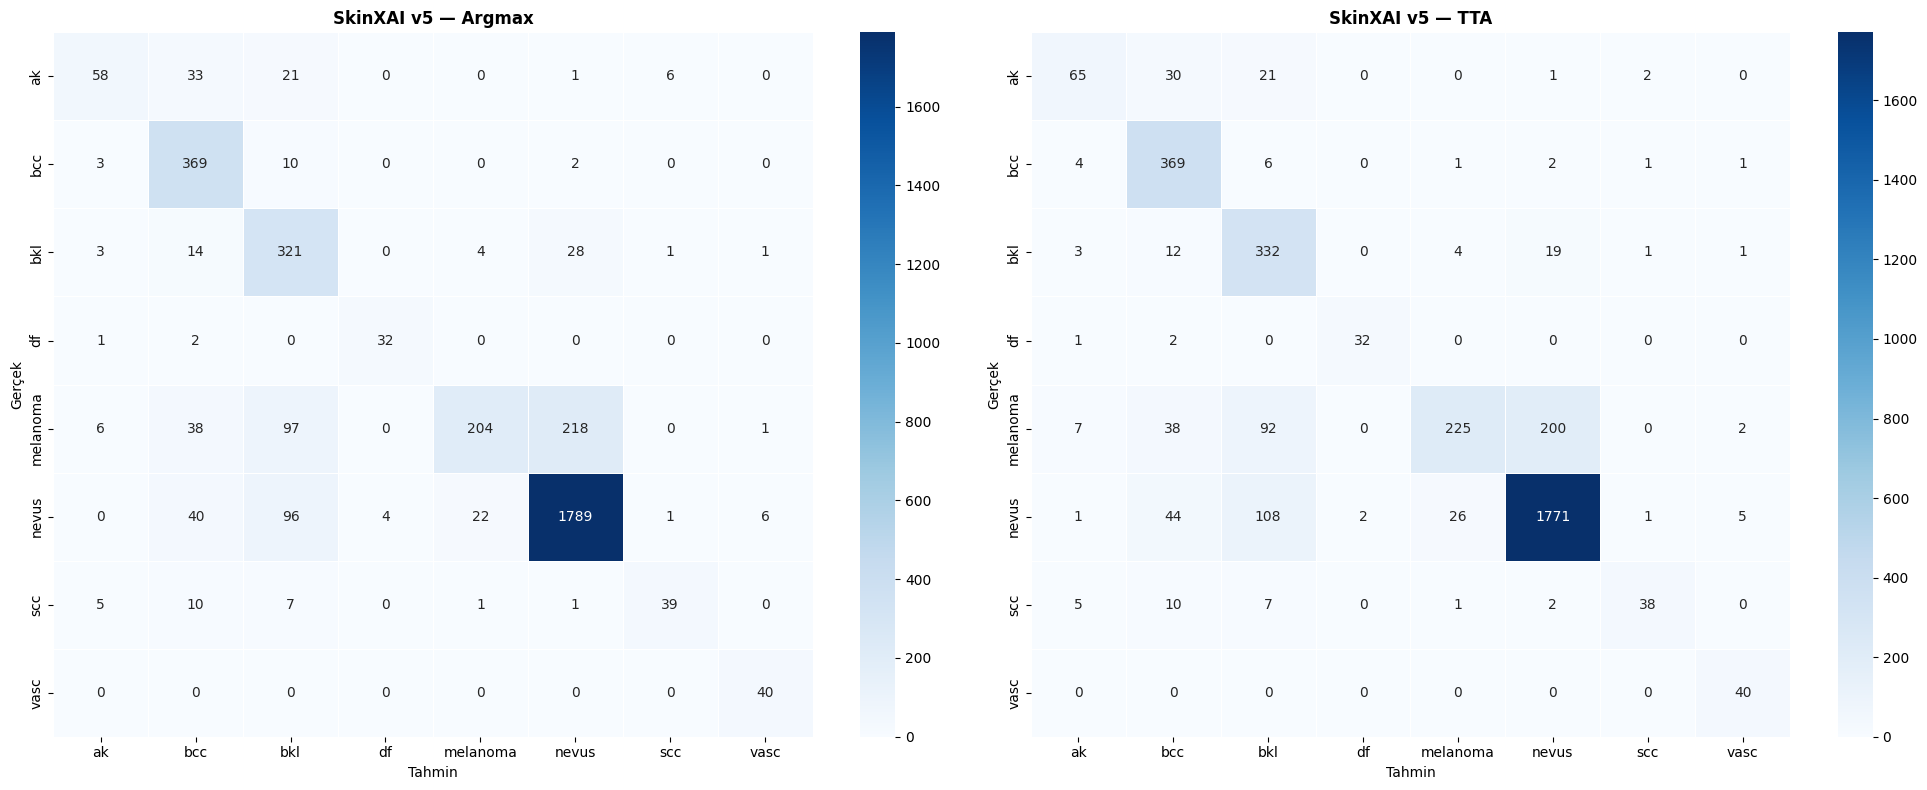


✅ Grafik kaydedildi: /kaggle/working/models_v5/cm_v5.png


In [28]:
# ── 16. Threshold Optimizasyonu + Confusion Matrix ──────────────
# Test tahminlerini tazele — threshold döngüsü tp/tl değişkenlerini eziyor
# Bu satırlar hücre kaç kez çalıştırılırsa çalıştırılsın doğru sonuç verir
ckpt_loaded = torch.load(SAVE_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt_loaded['model_state_dict'])
_, _, _, test_preds_arg, test_labels_arg = eval_epoch(model, test_loader, device)
print(f'Test preds: {test_preds_arg.shape}  Labels: {test_labels_arg.shape}')

# Val üzerinde per-class threshold bul
@torch.no_grad()
def get_probs(model, df, device, bs=32):
    model.eval()
    class D(Dataset):
        def __init__(self,df): self.df=df.reset_index(drop=True)
        def __len__(self): return len(self.df)
        def __getitem__(self,i):
            r=self.df.iloc[i]; img=cv2.imread(r['image_path'])
            img=np.zeros((224,224,3),dtype=np.uint8) if img is None else cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
            return AUG_VAL(image=img)['image'], int(r['label_idx'])
    ld=DataLoader(D(df),bs,shuffle=False,num_workers=2,pin_memory=True)
    probs,labs=[],[]
    for imgs,l in ld:
        probs.extend(torch.softmax(model(imgs.to(device)),1).cpu().numpy()); labs.extend(l.numpy())
    return np.array(probs), np.array(labs)

vp, vt = get_probs(model, val_pool, device)
thresholds={}
print(f'  {"Sınıf":12s} {"Threshold":>10} {"Recall":>8} {"F1":>8}')
print('  '+'-'*44)
for i, cls in enumerate(CLASS_NAMES):
    bf=0; bt=0.5
    for thr in np.arange(0.10,0.80,0.02):
        pb=(vp[:,i]>=thr).astype(int); tb=(vt==i).astype(int)
        tp=((pb==1)&(tb==1)).sum(); fp=((pb==1)&(tb==0)).sum(); fn=((pb==0)&(tb==1)).sum()
        if (tp+fp)==0 or (tp+fn)==0: continue
        pr=tp/(tp+fp); rc=tp/(tp+fn); f=2*pr*rc/(pr+rc+1e-9)
        if f>bf: bf=f; bt=thr
    thresholds[cls]=round(bt,2)
    rec=((vp[:,i]>=bt)&(vt==i)).sum()/max((vt==i).sum(),1)
    print(f'  {cls:12s} {bt:10.2f} {rec:8.3f} {bf:8.3f}')
print('\npredict.py RISK_THRESHOLDS için önerilen değerler:')
for cls in ['melanoma','bcc','scc','ak']:
    print(f'  "{cls}": {max(thresholds[cls]-0.08, 0.15):.2f},')

# Confusion matrix
fig, axes = plt.subplots(1,2,figsize=(20,8))
for ax, (preds, lbl) in zip(axes, [(test_preds_arg, test_labels_arg), (tta_p,tta_l)]):
    cm = confusion_matrix(lbl, preds)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES, cmap='Blues', linewidths=.4, ax=ax)
    ax.set_title(f'SkinXAI v5 — {"Argmax" if preds is test_preds_arg else "TTA"}',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Gerçek'); ax.set_xlabel('Tahmin')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/cm_v5.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✅ Grafik kaydedildi: {SAVE_DIR}/cm_v5.png')

In [29]:
# ── 17. Final Model — predict.py Uyumlu ────────────────────────
final_path = f'{SAVE_DIR}/skinxai_v5_final.pth'
torch.save({
    'model_state_dict':      model.state_dict(),
    'class_names':           CLASS_NAMES,
    'val_f1':                ckpt['val_f1'],
    'test_f1_tta':           float(tta_f1),
    'test_acc_tta':          float(tta_acc),
    'per_class_recall_tta':  tta_pc.tolist(),
    'thresholds':            thresholds,
}, final_path)

print(f'✅ Model kaydedildi: {final_path}')
print()
print('📥 İndirmek için sağ panelde "Output" sekmesine tıkla.')
print()
print('predict.py RISK_THRESHOLDS (bunu predict.py\'e yapıştır):')
print('RISK_THRESHOLDS = {')
for cls in ['melanoma','bcc','scc','ak']:
    thr = max(thresholds[cls]-0.08, 0.15)
    print(f'    "{cls}": {thr:.2f},')
print('}')
print()
print(f'TTA Accuracy : {tta_acc*100:.1f}%')
print(f'TTA Macro-F1 : {tta_f1:.4f}')
for i,cls in enumerate(CLASS_NAMES):
    d=(tta_pc[i]-V3[cls])*100
    print(f'  {cls:12s}: {tta_pc[i]*100:.1f}% ({d:+.1f}%)')

✅ Model kaydedildi: /kaggle/working/models_v5/skinxai_v5_final.pth

📥 İndirmek için sağ panelde "Output" sekmesine tıkla.

predict.py RISK_THRESHOLDS (bunu predict.py'e yapıştır):
RISK_THRESHOLDS = {
    "melanoma": 0.15,
    "bcc": 0.42,
    "scc": 0.24,
    "ak": 0.34,
}

TTA Accuracy : 81.2%
TTA Macro-F1 : 0.7700
  ak          : 54.6% (-33.1%)
  bcc         : 96.1% (+8.6%)
  bkl         : 89.2% (+22.5%)
  df          : 91.4% (+8.3%)
  melanoma    : 39.9% (-19.8%)
  nevus       : 90.4% (+3.0%)
  scc         : 60.3% (+6.3%)
  vasc        : 100.0% (+3.8%)
